In [2]:
import pandas as pd
import numpy as np

# Instrucción: Carga tu archivo limpio. 
# Si no lo tienes a la mano, usa el siguiente bloque para descargar y pre-limpiar lo básico:

url = "https://raw.githubusercontent.com/mricardo89/data-mining/refs/heads/main/Unit-III/datasets/players_data-2025_2026.csv"
df = pd.read_csv(url)


FASE 1 : Construyendo el Multiverso del Jugador (Min. 4 Dimensiones)

1. Construyan la matriz multidimensional X seleccionando al menos 4 características numéricas (pueden ser más) continuas (float) que definan el rendimiento del jugador (por ejemplo: Goles, Asistencias, Minutos_Jugados, Precisión_Pases, Recuperaciones, etc.).

In [ ]:
feature_cols = ['Gls', 'Ast', 'G+A', 'Int', 'Crs', 'TklW']
X_matrix = df[feature_cols].dropna().to_numpy(dtype=float)

df_X = pd.DataFrame(X_matrix, columns=feature_cols)
print("Shape:", df_X.shape)
print(df_X.head())

Shape: (2839, 6)
   Gls  Ast  G+A   Int   Crs  TklW
0  4.0  5.0  9.0  17.0  37.0  27.0
1  0.0  0.0  0.0   1.0   0.0   0.0
2  0.0  0.0  0.0   2.0   3.0   4.0
3  2.0  0.0  2.0   3.0  30.0   3.0
4  0.0  0.0  0.0   2.0   1.0   1.0


2. Creen un vector para su jugador estrella y otro vector para el resto de los candidatos.

In [ ]:
jugador_estrella = "Pedri"

idx_star = df.index[df["Player"] == jugador_estrella][0]

media = X_matrix.mean(axis=0, keepdims=True)
desviacion = X_matrix.std(axis=0, keepdims=True)
X_zscore = (X_matrix - media) / desviacion

vector_pedri = X_zscore[df.index.get_loc(idx_star)]

mask_restantes = np.ones(len(X_zscore), dtype=bool)
mask_restantes[df.index.get_loc(idx_star)] = False

resto_candidatos = X_zscore[mask_restantes]

3. Pregunta de control: Antes de medir cualquier distancia, ¿qué operación de la Unidad II deben aplicarle obligatoriamente a estas 4 columnas para que los Minutos_Jugados (rango en miles) no aplasten matemáticamente a los Goles (rango en decenas)? Apliquen esa transformación en el código.

Lo que se debe realizar es una tecnica de escalamiento para evitar el desborde matematico al momento de realizar las predicciones, por lo que es necesario aplicar en este caso el Z-Score para obtener una estandarizavion correcta de los valores de las stats.


Fase 2: El Duelo de Distancias (Euclidiana vs. Manhattan)

Programen una celda para encontrar al jugador más similar a su estrella usando la Distancia Euclidiana. Impriman el nombre del reemplazo sugerido.

In [ ]:
# Distancia Euclidiana para encontrar al jugador más similar a la estrella

candidate_indices = np.where(mask_restantes)[0]

distancias = np.linalg.norm(resto_candidatos - vector_pedri, axis=1)

best_local_idx = np.argmin(distancias)
best_original_idx = candidate_indices[best_local_idx]

jugador_sugerido = df.loc[best_original_idx, "Player"]

print(f"Jugador estrella: {jugador_estrella}")
print(f"Reemplazo sugerido (Distancia Euclidiana): {jugador_sugerido}")

Jugador estrella: Pedri
Reemplazo sugerido (Distancia Euclidiana): Konrad Laimer


En la siguiente celda, busquen al reemplazo calculando la Distancia Manhattan (deberán generar una función custom para calcular esta distancia).

In [7]:
# Distancia Manhattan para encontrar al jugador más similar a la estrella

def manhattan_distance(a, b):
    # a y b pueden ser arrays 1D o 2D; calcula la suma de diferencias absolutas
    return np.abs(a - b).sum(axis=1)


candidate_indices = np.where(mask_restantes)[0]

distancias_manhattan = manhattan_distance(resto_candidatos, vector_pedri)

best_local_idx_manhattan = np.argmin(distancias_manhattan)
best_original_idx_manhattan = candidate_indices[best_local_idx_manhattan]

# Nombre del reemplazo sugerido
jugador_sugerido_manhattan = df.loc[best_original_idx_manhattan, "Player"]

print(f"Jugador estrella: {jugador_estrella}")
print(f"Reemplazo sugerido (Distancia Manhattan): {jugador_sugerido_manhattan}")
print(f"Distancia Manhattan mínima: {distancias_manhattan[best_local_idx_manhattan]}")

Jugador estrella: Pedri
Reemplazo sugerido (Distancia Manhattan): Konrad Laimer
Distancia Manhattan mínima: 2.5632016248903806


Análisis Crítico: ¿El algoritmo sugirió al mismo jugador en ambos casos? Como ingenieros, expliquen en un bloque de Markdown las diferencias observables entre la Distancia Euclidiana comparado con la Distancia Manhattan.

Si fue lo mismo, me sugirio al mismo jugador, las diferencias marcables entre ambas busquedas es que a diferencia de lka distancia Euclidiana que se basa en el teorema de pitagoras para encopntrar las distancias mas cortas, la distancia manhathan la suma de las diferencias absolutas entre los dos vectores, usando solo ejes verticales y verticales.


Fase 3: El Reto de Visualización en 4D (Investigación Independiente)

Investiguen y elijan una técnica o librería en Python que les permita proyectar visualmente vectores de 4 dimensiones o más en una pantalla 2D.(Pistas que pueden investigar: Gráficos de Radar / Spider Charts, Coordenadas Paralelas, o el uso de color/tamaño como cuartas dimensiones en un Scatter 3D).


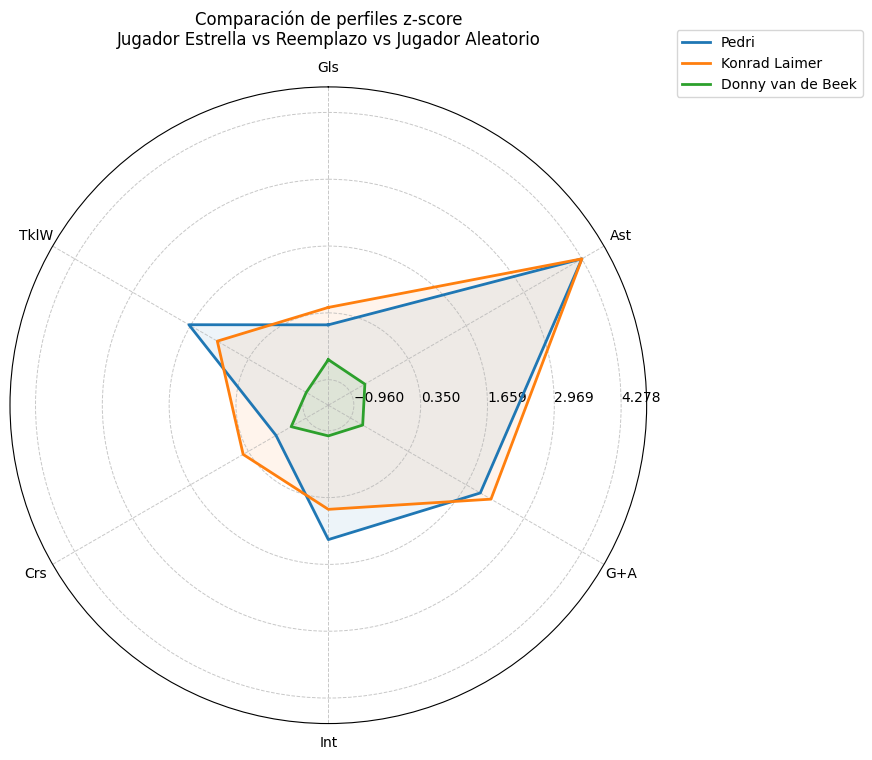

In [9]:
import numpy as np

import matplotlib.pyplot as plt

# 1) Selección de jugadores a comparar
star_name = jugador_estrella
suggested_name = jugador_sugerido

# Índices del jugador estrella y del sugerido
star_idx = df.index[df["Player"] == star_name][0]
suggested_idx = df.index[df["Player"] == suggested_name][0]

# Vectores z-score para los tres perfiles
vector_star = X_zscore[star_idx]
vector_suggested = X_zscore[suggested_idx]

# 2) Tercer jugador aleatorio distinto de los dos anteriores
pool = df[~df["Player"].isin([star_name, suggested_name])]["Player"].dropna().tolist()
rng = np.random.default_rng(42) 
random_name = rng.choice(pool)
random_idx = df.index[df["Player"] == random_name][0]
vector_random = X_zscore[random_idx]

players = [star_name, suggested_name, random_name]
vectors = np.vstack([vector_star, vector_suggested, vector_random])

# 3) Visualización en radar chart (gráfico 2D para 6 dimensiones)
labels = feature_cols
N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

max_val = np.max(vectors)
min_val = np.min(vectors)
ax.set_ylim(min_val - 0.5, max_val + 0.5)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)
ax.set_rlabel_position(90)
ax.set_yticks(np.linspace(min_val, max_val, 5))
ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)

for i, profile in enumerate(vectors):
    values = np.concatenate([profile, profile[:1]])
    ax.plot(angles, values, linewidth=2, label=players[i])
    ax.fill(angles, values, alpha=0.08)

ax.set_title("Comparación de perfiles z-score\nJugador Estrella vs Reemplazo vs Jugador Aleatorio", pad=30)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.10))
plt.tight_layout()
plt.show()